In [12]:
import pandas as pd
import plotly.express as px

scores = pd.read_csv("../data/processed/churn_dashboard_dataset.csv")
scores.head()

,Risk_Tier,Churn_Prob,Actual_Churn,Expected_Annual_Loss,Contract,InternetService,PaymentMethod,tenure,MonthlyCharges
0,Low,0.018176,0,16.565421,Two year,DSL,Credit card (automatic),59,75.95
1,Medium,0.591408,0,557.461415,Month-to-month,Fiber optic,Bank transfer (automatic),7,78.55
2,Low,0.004945,0,1.192749,Two year,No,Mailed check,54,20.10
3,Low,0.200697,1,49.732754,Month-to-month,No,Mailed check,2,20.65
4,Low,0.103671,0,130.812474,Two year,Fiber optic,Bank transfer (automatic),71,105.15


In [13]:
scores["Value_Tier"] = pd.qcut(
    scores["Expected_Annual_Loss"],
    q=2,
    labels=["Low Value", "High Value"]
)

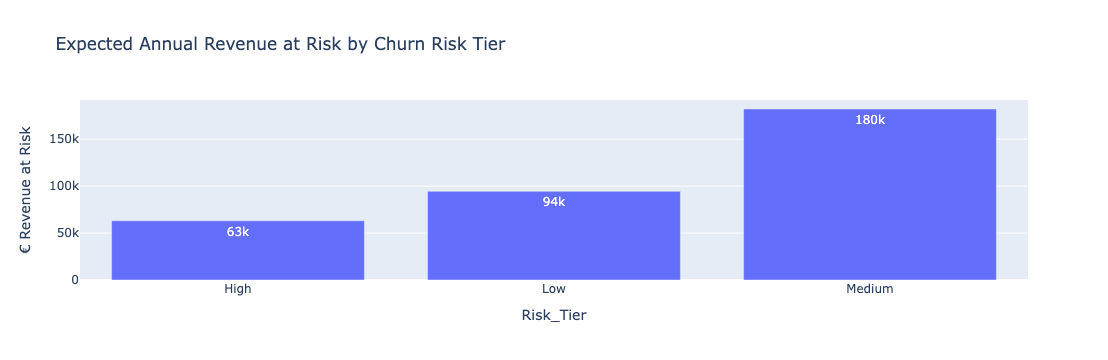

In [14]:
rev_risk = (
    scores
    .groupby("Risk_Tier", as_index=False)
    .agg(Expected_Annual_Loss=("Expected_Annual_Loss", "sum"))
)

fig1 = px.bar(
    rev_risk,
    x="Risk_Tier",
    y="Expected_Annual_Loss",
    title="Expected Annual Revenue at Risk by Churn Risk Tier",
    text_auto=".2s"
)

fig1.update_layout(yaxis_title="€ Revenue at Risk")
fig1.show()

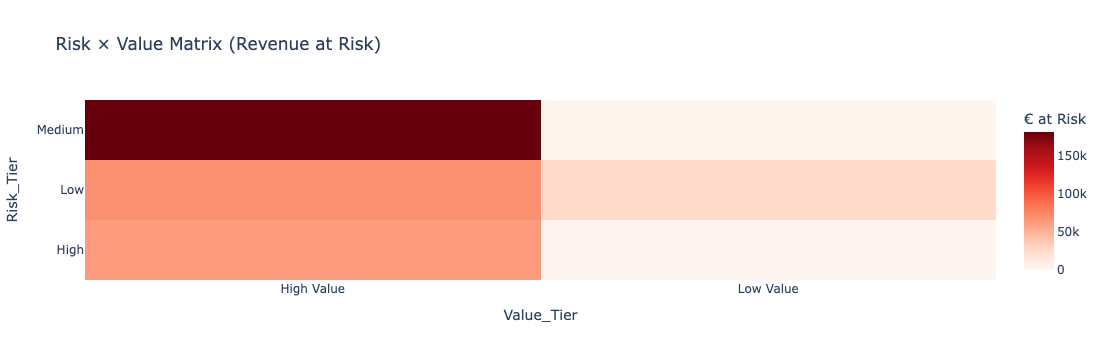

In [15]:
matrix = (
    scores
    .groupby(["Risk_Tier", "Value_Tier"])
    .agg(
        customers=("Actual_Churn", "count"),
        revenue_at_risk=("Expected_Annual_Loss", "sum")
    )
    .reset_index()
)

fig2 = px.density_heatmap(
    matrix,
    x="Value_Tier",
    y="Risk_Tier",
    z="revenue_at_risk",
    color_continuous_scale="Reds",
    title="Risk × Value Matrix (Revenue at Risk)"
)

fig2.update_layout(coloraxis_colorbar_title="€ at Risk")
fig2.show()

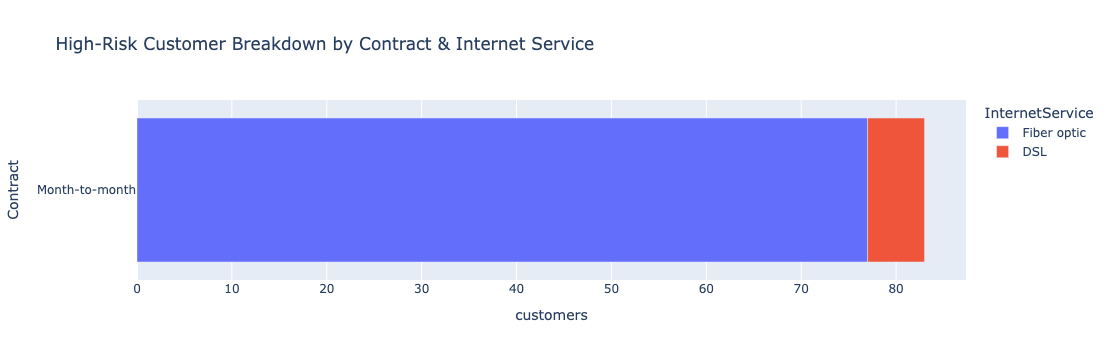

In [16]:
high_risk = scores[scores["Risk_Tier"] == "High"]

drivers = (
    high_risk
    .groupby(["Contract", "InternetService"])
    .size()
    .reset_index(name="customers")
    .sort_values("customers", ascending=False)
)

fig3 = px.bar(
    drivers,
    x="customers",
    y="Contract",
    color="InternetService",
    orientation="h",
    title="High-Risk Customer Breakdown by Contract & Internet Service"
)

fig3.show()

In [17]:
fig1.write_image("../reports/figures/revenue_at_risk_by_tier.png")
fig2.write_image("../reports/figures/risk_value_matrix.png")
fig3.write_image("../reports/figures/high_risk_driver_breakdown.png")